# Infrastructure -> Application Contract Preview

Ten notebook przygotowuje draft kontraktu wewnętrznego `Infrastructure -> Application` w ML.

Cel:
- oprzeć się na tym, co dziś realnie zwraca draft `raw_line_family_only`,
- przestać traktować payload transportowy jako główny kontrakt,
- upewnić się, że przyszła warstwa `Application` dostanie komplet danych potrzebnych do:
  - podglądu planszy po warp,
  - podziału planszy na `9x9`,
  - dataset preview,
  - preprocessingu wejścia modelu,
  - inferencji i treningu.

Punkt odniesienia dla zgodności z obecną produkcyjną architekturą to `CellPreprocessingPipeline` z `infrastructure/vision`.

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
import json
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start_path: Path | None = None) -> Path:
    current_path = (start_path or Path.cwd()).resolve()
    for candidate in [current_path, *current_path.parents]:
        if (candidate / ".ai").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root.")


REPO_ROOT = find_repo_root()
DRAFT_VARIANT_DIR = (
    REPO_ROOT / "src" / "MachineLearning" / "draft" / "raw_line_family_only"
)
ML_SRC_DIR = REPO_ROOT / "src" / "MachineLearning"
for search_path in [DRAFT_VARIANT_DIR, ML_SRC_DIR]:
    if str(search_path) not in sys.path:
        sys.path.insert(0, str(search_path))

import bootstrap
from infrastructure.vision.cell_preprocessing_pipeline import CellPreprocessingPipeline
from preprocessing_api import (
    ExtractCellsApiError,
    PreprocessBoardApiError,
    extract_cells_from_board_image,
    preprocess_board_image,
)

API = bootstrap.load_api()
plt.rcParams["figure.figsize"] = (18, 12)

In [ ]:
CONFIG = API.ExperimentConfig(
    selected_dataset_index=0,
    raw_hough_threshold=35,
    raw_min_line_length_ratio=0.08,
    raw_max_line_gap_ratio=0.005,
)
INPUT_IMAGE_PATH: str | None = None

GridUint8 = tuple[tuple[np.ndarray, ...], ...]
GridFloat32 = tuple[tuple[np.ndarray, ...], ...]


@dataclass(frozen=True, slots=True)
class InfrastructureBoardContract:
    warped_board_image: np.ndarray
    preprocessing_artifacts: object
    line_family_result: object


@dataclass(frozen=True, slots=True)
class InfrastructureCellsContract:
    grid_rows: int
    grid_cols: int
    min_cell_height_px: int
    min_cell_width_px: int
    raw_cells: GridUint8
    raw_preview_image: np.ndarray
    ml_ready_cell_size_px: int
    ml_ready_cells_uint8: GridUint8
    ml_ready_cells_float32: GridFloat32
    ml_ready_preview_image: np.ndarray


@dataclass(frozen=True, slots=True)
class InfrastructureVisionContract:
    board: InfrastructureBoardContract
    cells: InfrastructureCellsContract


def resolve_input_image_path(input_image_path: str | None) -> Path:
    if input_image_path:
        return Path(input_image_path).expanduser().resolve()
    image_path, _ = API.resolve_active_image_path(CONFIG)
    return image_path


def bgr_to_rgb(image: np.ndarray) -> np.ndarray:
    if image.ndim == 2:
        return image
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def build_float32_grid(
    cell_pipeline: CellPreprocessingPipeline,
    raw_cells: GridUint8,
) -> GridFloat32:
    return tuple(
        tuple(cell_pipeline.run(cell_image) for cell_image in row)
        for row in raw_cells
    )


def build_uint8_grid_from_pipeline(
    cell_pipeline: CellPreprocessingPipeline,
    raw_cells: GridUint8,
) -> GridUint8:
    return tuple(
        tuple(cell_pipeline.run_uint8(cell_image) for cell_image in row)
        for row in raw_cells
    )


def grid_cell_shape(grid: tuple[tuple[np.ndarray, ...], ...]) -> tuple[int, ...]:
    return tuple(grid[0][0].shape)


def assert_grid_dimensions(
    grid: tuple[tuple[np.ndarray, ...], ...],
    rows: int,
    cols: int,
) -> None:
    assert len(grid) == rows
    assert all(len(row) == cols for row in grid)


def all_uint8_cells_equal(left: GridUint8, right: GridUint8) -> bool:
    return all(
        np.array_equal(left_cell, right_cell)
        for left_row, right_row in zip(left, right)
        for left_cell, right_cell in zip(left_row, right_row)
    )


def all_float32_cells_close(left: GridFloat32, right: GridFloat32) -> bool:
    return all(
        np.allclose(left_cell, right_cell)
        for left_row, right_row in zip(left, right)
        for left_cell, right_cell in zip(left_row, right_row)
    )

In [ ]:
input_image_path = resolve_input_image_path(INPUT_IMAGE_PATH)
source_bgr = API.load_image_bgr(input_image_path)

try:
    preprocess_result = preprocess_board_image(
        source_bgr=source_bgr,
        config=CONFIG,
    )
except PreprocessBoardApiError as error:
    raise RuntimeError(
        f"Board preprocess failed: {error.error_type} -> {error.message}"
    ) from error

try:
    extract_result = extract_cells_from_board_image(
        board_image=preprocess_result.warped_board_image,
        config=CONFIG,
    )
except ExtractCellsApiError as error:
    raise RuntimeError(
        f"Cells extract failed: {error.error_type} -> {error.message}"
    ) from error

cell_pipeline = CellPreprocessingPipeline(
    output_size=extract_result.cells_grid_result.ml_ready_cell_size_px,
    adaptive_block_size=CONFIG.adaptive_threshold_block_size,
    adaptive_c=CONFIG.adaptive_threshold_c_value,
    border_clearance_px=0,
    min_component_area_ratio=0.0,
)

pipeline_uint8_grid = build_uint8_grid_from_pipeline(
    cell_pipeline=cell_pipeline,
    raw_cells=extract_result.cells_grid_result.cells,
)
pipeline_float32_grid = build_float32_grid(
    cell_pipeline=cell_pipeline,
    raw_cells=extract_result.cells_grid_result.cells,
)

contract = InfrastructureVisionContract(
    board=InfrastructureBoardContract(
        warped_board_image=preprocess_result.warped_board_image,
        preprocessing_artifacts=preprocess_result.preprocessing_artifacts,
        line_family_result=preprocess_result.line_family_result,
    ),
    cells=InfrastructureCellsContract(
        grid_rows=extract_result.cells_grid_result.grid_rows,
        grid_cols=extract_result.cells_grid_result.grid_cols,
        min_cell_height_px=extract_result.cells_grid_result.min_cell_height_px,
        min_cell_width_px=extract_result.cells_grid_result.min_cell_width_px,
        raw_cells=extract_result.cells_grid_result.cells,
        raw_preview_image=extract_result.cells_grid_result.preview_image,
        ml_ready_cell_size_px=extract_result.cells_grid_result.ml_ready_cell_size_px,
        ml_ready_cells_uint8=extract_result.cells_grid_result.ml_ready_cells,
        ml_ready_cells_float32=pipeline_float32_grid,
        ml_ready_preview_image=extract_result.cells_grid_result.ml_ready_preview_image,
    ),
)

assert preprocess_result.line_family_result.selected_logical_line_frame_warp_result is not None
assert_grid_dimensions(contract.cells.raw_cells, contract.cells.grid_rows, contract.cells.grid_cols)
assert_grid_dimensions(
    contract.cells.ml_ready_cells_uint8,
    contract.cells.grid_rows,
    contract.cells.grid_cols,
)
assert_grid_dimensions(
    contract.cells.ml_ready_cells_float32,
    contract.cells.grid_rows,
    contract.cells.grid_cols,
)
assert all_uint8_cells_equal(contract.cells.ml_ready_cells_uint8, pipeline_uint8_grid)
assert all_float32_cells_close(contract.cells.ml_ready_cells_float32, pipeline_float32_grid)

contract_invariants = {
    "inputImagePath": str(input_image_path),
    "gridRows": contract.cells.grid_rows,
    "gridCols": contract.cells.grid_cols,
    "rawCellShape": grid_cell_shape(contract.cells.raw_cells),
    "mlReadyCellShapeUint8": grid_cell_shape(contract.cells.ml_ready_cells_uint8),
    "mlReadyCellShapeFloat32": grid_cell_shape(contract.cells.ml_ready_cells_float32),
    "matchesInfrastructureCellPipelineUint8": all_uint8_cells_equal(
        contract.cells.ml_ready_cells_uint8,
        pipeline_uint8_grid,
    ),
    "matchesInfrastructureCellPipelineFloat32": all_float32_cells_close(
        contract.cells.ml_ready_cells_float32,
        pipeline_float32_grid,
    ),
}
print(json.dumps(contract_invariants, indent=2, ensure_ascii=False))

{
  "inputImagePath": "/home/wojtek/projects/sudoku/data/raw/boards/mixed/image25.jpg",
  "gridRows": 9,
  "gridCols": 9,
  "rawCellShape": [
    80,
    80,
    3
  ],
  "mlReadyCellShapeUint8": [
    28,
    28
  ],
  "mlReadyCellShapeFloat32": [
    28,
    28
  ],
  "matchesInfrastructureCellPipelineUint8": true,
  "matchesInfrastructureCellPipelineFloat32": true
}


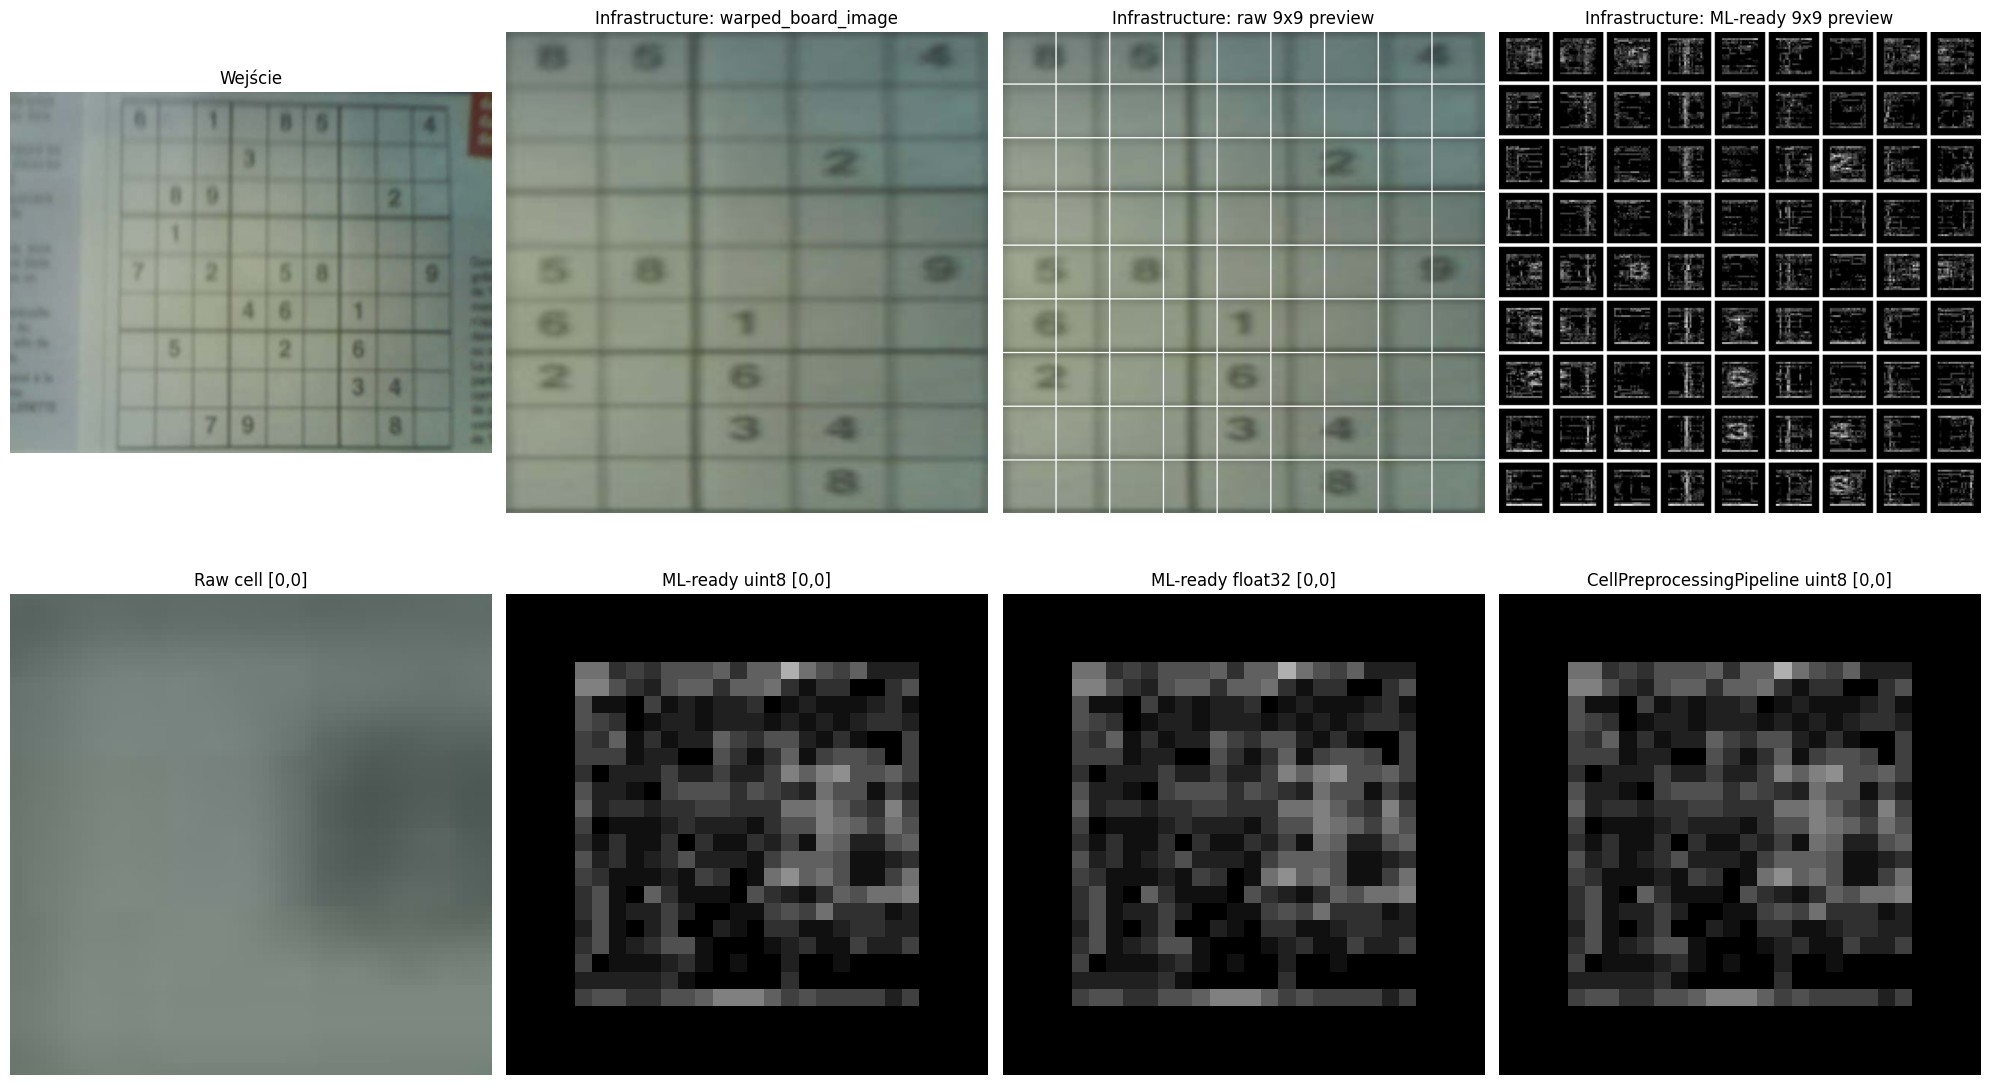

In [ ]:
example_row_index = 0
example_col_index = 0
example_raw_cell = contract.cells.raw_cells[example_row_index][example_col_index]
example_ml_ready_uint8 = contract.cells.ml_ready_cells_uint8[example_row_index][
    example_col_index
]
example_ml_ready_float32 = contract.cells.ml_ready_cells_float32[example_row_index][
    example_col_index
]
example_pipeline_uint8 = pipeline_uint8_grid[example_row_index][example_col_index]

figure, axes = plt.subplots(2, 4, figsize=(20, 12))

axes[0, 0].imshow(bgr_to_rgb(source_bgr))
axes[0, 0].set_title("Wejście")

axes[0, 1].imshow(bgr_to_rgb(contract.board.warped_board_image))
axes[0, 1].set_title("Infrastructure: warped_board_image")

axes[0, 2].imshow(bgr_to_rgb(contract.cells.raw_preview_image))
axes[0, 2].set_title("Infrastructure: raw 9x9 preview")

axes[0, 3].imshow(contract.cells.ml_ready_preview_image, cmap="gray", vmin=0, vmax=255)
axes[0, 3].set_title("Infrastructure: ML-ready 9x9 preview")

axes[1, 0].imshow(bgr_to_rgb(example_raw_cell))
axes[1, 0].set_title("Raw cell [0,0]")

axes[1, 1].imshow(example_ml_ready_uint8, cmap="gray", vmin=0, vmax=255)
axes[1, 1].set_title("ML-ready uint8 [0,0]")

axes[1, 2].imshow(example_ml_ready_float32, cmap="gray", vmin=0.0, vmax=1.0)
axes[1, 2].set_title("ML-ready float32 [0,0]")

axes[1, 3].imshow(example_pipeline_uint8, cmap="gray", vmin=0, vmax=255)
axes[1, 3].set_title("CellPreprocessingPipeline uint8 [0,0]")

for axis in axes.ravel():
    axis.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
contract_summary = {
    "boardContract": {
        "warpedBoardShape": tuple(contract.board.warped_board_image.shape),
        "displayShape": tuple(
            contract.board.preprocessing_artifacts.display_bgr.shape
        ),
        "grayShape": tuple(contract.board.preprocessing_artifacts.gray_image.shape),
        "binaryShape": tuple(contract.board.preprocessing_artifacts.binary_image.shape),
        "cleanBinaryShape": tuple(
            contract.board.preprocessing_artifacts.clean_binary.shape
        ),
        "repairedBinaryShape": tuple(
            contract.board.preprocessing_artifacts.repaired_binary.shape
        ),
        "selectedWarpAvailable": (
            contract.board.line_family_result.selected_logical_line_frame_warp_result
            is not None
        ),
        "horizontalLogicalLines": len(
            contract.board.line_family_result.horizontal_logical_lines
        ),
        "verticalLogicalLines": len(
            contract.board.line_family_result.vertical_logical_lines
        ),
    },
    "cellsContract": {
        "gridRows": contract.cells.grid_rows,
        "gridCols": contract.cells.grid_cols,
        "minCellHeightPx": contract.cells.min_cell_height_px,
        "minCellWidthPx": contract.cells.min_cell_width_px,
        "rawCellShape": grid_cell_shape(contract.cells.raw_cells),
        "mlReadyCellSizePx": contract.cells.ml_ready_cell_size_px,
        "mlReadyCellShapeUint8": grid_cell_shape(contract.cells.ml_ready_cells_uint8),
        "mlReadyCellShapeFloat32": grid_cell_shape(
            contract.cells.ml_ready_cells_float32
        ),
        "rawPreviewShape": tuple(contract.cells.raw_preview_image.shape),
        "mlReadyPreviewShape": tuple(contract.cells.ml_ready_preview_image.shape),
        "matchesInfrastructureCellPipelineUint8": all_uint8_cells_equal(
            contract.cells.ml_ready_cells_uint8,
            pipeline_uint8_grid,
        ),
        "matchesInfrastructureCellPipelineFloat32": all_float32_cells_close(
            contract.cells.ml_ready_cells_float32,
            pipeline_float32_grid,
        ),
    },
}

print("Kontrakt wewnętrzny Infrastructure -> Application:")
print(json.dumps(contract_summary, indent=2, ensure_ascii=False))

print("\nWniosek operacyjny:")
print(
    "Application dostaje warped board, raw 9x9 cells, ML-ready uint8 preview/grid "
    "oraz ML-ready float32 zgodny z CellPreprocessingPipeline."
)

Kontrakt wewnętrzny Infrastructure -> Application:
{
  "boardContract": {
    "warpedBoardShape": [
      720,
      720,
      3
    ],
    "displayShape": [
      480,
      640,
      3
    ],
    "grayShape": [
      480,
      640
    ],
    "binaryShape": [
      480,
      640
    ],
    "cleanBinaryShape": [
      480,
      640
    ],
    "repairedBinaryShape": [
      480,
      640
    ],
    "selectedWarpAvailable": true,
    "horizontalLogicalLines": 9,
    "verticalLogicalLines": 11
  },
  "cellsContract": {
    "gridRows": 9,
    "gridCols": 9,
    "minCellHeightPx": 80,
    "minCellWidthPx": 80,
    "rawCellShape": [
      80,
      80,
      3
    ],
    "mlReadyCellSizePx": 28,
    "mlReadyCellShapeUint8": [
      28,
      28
    ],
    "mlReadyCellShapeFloat32": [
      28,
      28
    ],
    "rawPreviewShape": [
      736,
      736,
      3
    ],
    "mlReadyPreviewShape": [
      268,
      268
    ],
    "matchesInfrastructureCellPipelineUint8": true,
    "mat

## Wniosek dla warstwy Application

Docelowym kontraktem wewnętrznym nie powinny być payloady transportowe, tylko obiekty podobne do:
- `InfrastructureBoardContract`
- `InfrastructureCellsContract`
- `InfrastructureVisionContract`

W praktyce Application powinno móc liczyć na to, że Infrastructure odda:
- `warped_board_image`,
- etapy preprocessingu planszy potrzebne do diagnostyki,
- `raw_cells` jako wycinki `9x9`,
- `raw_preview_image` jako mozaikę do preview datasetu,
- `ml_ready_cells_uint8` jako wariant preview / zapis artefaktów,
- `ml_ready_cells_float32` jako wariant wejściowy zgodny z obecną Application i `CellPreprocessingPipeline`,
- `ml_ready_preview_image` jako podgląd jakości danych po preprocessingu modelowym.

Najważniejszy wniosek z tego notebooka:
- obecny draft `raw_line_family_only` już zwraca prawie cały potrzebny materiał,
- dla przyszłej warstwy `Infrastructure -> Application` kluczowe jest utrzymanie także wariantu `float32`, bo to na nim pracują obecne use-case'y inferencji i przygotowania datasetu.